In [ ]:
#  Kmeans Algorithm: 
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from ml_implement.general_utils.data_read import DataReader
from ml_implement.general_utils.univershal_plotter import UniversalPlotter
from loaddata import *


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import plotly.graph_objects as go

# -----------------------------
# 1D dataset with 3 separated groups
# (creates clearer multiple valleys)
# -----------------------------
X = np.array([
    -5, -4.5, -4, -3.5,
     0, 0.5, 1,
     8, 9, 10, 11
])

m = len(X)

# -----------------------------
# K-means Cost/distortion (K=2)
# -----------------------------
def kmeans_cost(mu1, mu2):
    cost = 0
    for x in X:
        dist1 = (x - mu1)**2    # calculate distance with first centroid.
        dist2 = (x - mu2)**2    # calculate distance with second centroid.
        cost += min(dist1, dist2) 
    return cost / m

# -----------------------------
# Grid of centroid values
# -----------------------------
mu1_vals = np.linspace(-6, 11, 200)
mu2_vals = np.linspace(-6, 11, 200)

MU1, MU2 = np.meshgrid(mu1_vals, mu2_vals)
J = np.zeros(MU1.shape)

for i in range(MU1.shape[0]):
    for j in range(MU1.shape[1]):
        J[i, j] = kmeans_cost(MU1[i, j], MU2[i, j])


# 1. Setup figure with a clean, high-resolution size
fig = plt.figure(figsize=(8.5, 5.5), dpi=100)
fig.set_facecolor('white') # White is usually more professional than grey for portfolios

# 2. Add 3D axes with specific positioning to avoid label clipping
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)
ax.set_facecolor('white')

# 3. Plot the surface with a high-quality colormap and antialiasing
surf = ax.plot_surface(MU1, MU2, J, 
                       cmap='viridis', 
                       edgecolor='none', 
                       alpha=0.9, 
                       antialiased=True)

# 4. Professional Labeling with LaTeX
ax.set_xlabel(r'$\mu_1$ (Centroid 1)', fontsize=12, labelpad=10)
ax.set_ylabel(r'$\mu_2$ (Centroid 2)', fontsize=12, labelpad=10)
ax.set_zlabel(r'Distortion $J(\mu_1, \mu_2)$', fontsize=12, labelpad=15)

# 5. Add a bold, clear title
# plt.title('K-Means Distortion Cost Surface', fontsize=15, fontweight='bold', pad=20)
ax.set_title("Total kmeans Cost(J) for different random initialization of centers($\mu_1$, $\mu_2$)",fontsize=15, fontweight='bold', pad=10)

# 6. Adjust the viewing angle to ensure Z-label visibility
# elev=30 (tilt), azim=-60 (rotation) is the standard "best" view
ax.view_init(elev=25, azim=-60)

# 7. Add a colorbar to help with data interpretation
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)

# 8. Use subplots_adjust instead of tight_layout for 3D (more control)
plt.subplots_adjust(left=0, right=1, bottom=0, top=0.9)
# Add this before plt.show()
ax.contour(MU1, MU2, J, zdir='z', offset=np.min(J), cmap='viridis', alpha=0.5)
plt.show()


# -----------------------------
# Plotly 3D Surface
# -----------------------------
fig = go.Figure(
    data=[
        go.Surface(
            x=MU1,
            y=MU2,
            z=J,
            colorscale='Viridis'
        )
    ]
)

fig.update_layout(
    title="K-means Cost Surface (K=2, 1D Data)",
    scene=dict(
        xaxis_title="Centroid μ1",
        yaxis_title="Centroid μ2",
        zaxis_title="Distortion J"
    ),
    width=700,
    height=500
)
# fig.show(renderer="png") 
# Or use "svg" for higher quality
fig.show()

### norm: **np.linalg.norm()**
 - it is a function in the NumPy library used to calculate the norm of a vector or matrix. 
 - By default, when applied to a vector (or the difference between two vectors), it calculates the Euclidean Norm ($L^2$ norm), 
 - which represents the straight-line distance from the origin to that point in space.
2. **The Mathematical Formula:** 
 - The general formula for the $L^2$ (Euclidean) 
    norm of a vector $\mathbf{u}$ is:$$\|\mathbf{u}\|_2 = \sqrt{\sum_{i=1}^{n} |u_i|^2}$$ 
 - When used to find the distance between two vectors $\mathbf{x}$ and $\mathbf{y}$ (as in your code), the formula becomes:$$d(\mathbf{x}, \mathbf{y}) = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2 + \dots + (x_n - y_n)^2}$$
### **Comparison with Manual Calculation**
 - To understand what np.linalg.norm is doing "under the hood," it is exactly equivalent to this manual NumPy operation:
### These two lines produce the exact same result:
    dist_norm = np.linalg.norm(row - v)  --> using the norm
    dist_manual = np.sqrt(np.sum((row - v)**2)) --> uisng the simple distance formula.
    print(dist_norm == dist_manual) # True
### **Why use np.linalg.norm instead of the manual formula?** 
 -  Readability: The code clearly states you are calculating a "norm" (distance).Versatility: 
 -  You can calculate different types of distances by changing the ord (order) parameter.
 -  For example:Manhattan Distance ($L^1$): np.linalg.norm(vec, ord=1) $\rightarrow \sum |x_i|$ 
 -  Max Norm ($L^\infty$): np.linalg.norm(vec, ord=np.inf) $\rightarrow \max(|x_i|)$ 

 ``Performance``:
 -  It is highly optimized in C and Fortran to handle extremely large arrays much faster than manual Python loops.

In [ ]:
#  Mine -  Moh Rafik 

def find_closest_centroid(X,centroids):
    """
     X : is a matrix with m-training examples and n features.
    Centroid : K -> number of centroids. Mu1 = (mu_x1,mu_x2, .... mux_n) -> one center coordinates for initializations.
    output:
    index : return index, indexed each data point from 0(or 1),..K-1(or K).
    """    
    idx = np.zeros(X.shape[0], dtype=int) # --> indexing for each data points nearest to the  its centroids.
    k = centroids.shape[0]

    for i_row in range(X.shape[0]):
        euclidian_L2_bw_data_jth_centroid = [] # distance between one data example and ecah centroids.
        for j in range(k):
            dist_norm_ij = np.linalg.norm(X[i_row] - centroids[j]) 
            euclidian_L2_bw_data_jth_centroid.append(dist_norm_ij)

        idx_mindist= np.argmin(euclidian_L2_bw_data_jth_centroid)
        # if i want indexing start with 1 for centroids 1,2,..K in place of centroids: 0,1,2 .....K-1. 
        # idx_mindist = idx_mindist + 1 # increment each indexing by one.

        idx[i_row] = idx_mindist

    return idx   


# Vectorization: Optimizing K-Means Assignment Step: *``find closest_centroid()``* 

Vectorization replaces slow Python `for` loops with highly optimized NumPy operations that run in C. In K-Means, we use **Broadcasting** and the **Axis** parameter to compare one data point to all centroids at once.

## 1. The Mathematical Problem
For a single data point $\mathbf{x}$, we need to calculate the distance to all $K$ centroids $\boldsymbol{\mu}$ and find the smallest one:
$$d_j = \|\mathbf{x} - \boldsymbol{\mu}_j\|_2$$

## 2. Step-by-Step Example
Assume we have one data point and three centroids in 2D space:
- **Data Point ($x$):** `[2, 3]`
- **Centroids ($\mu$):**
    - $C_0: [1, 1]$
    - $C_1: [5, 5]$
    - $C_2: [2, 0]$

### Step A: Broadcasting Subtraction
When you execute `X[i_row] - centroids`, NumPy "stretches" the data point to match the shape of the centroids matrix:
$$
\begin{bmatrix} 2 & 3 \end{bmatrix} - \begin{bmatrix} 1 & 1 \\ 5 & 5 \\ 2 & 0 \end{bmatrix} = \begin{bmatrix} (2-1) & (3-1) \\ (2-5) & (3-5) \\ (2-2) & (3-0) \end{bmatrix} = \begin{bmatrix} 1 & 2 \\ -3 & -2 \\ 0 & 3 \end{bmatrix}
$$

### Step B: The `axis=1` Norm
By calling `np.linalg.norm(..., axis=1)`, NumPy calculates the magnitude of each row independently:
- **Row 0:** $\sqrt{1^2 + 2^2} \approx 2.23$
- **Row 1:** $\sqrt{(-3)^2 + (-2)^2} \approx 3.60$
- **Row 2:** $\sqrt{0^2 + 3^2} = 3.0$

**Result Array:** `[2.23, 3.60, 3.0]`

### Step C: Indexing
Using `np.argmin([2.23, 3.60, 3.0])` returns `0`, which is the index of the closest centroid.

---

## 3. Code Comparison

### Original (Nested Loop) - Slow
```python
for i_row in range(X.shape[0]):
        euclidian_L2_bw_data_jth_centroid = [] # distance between one data example and ecah centroids.
        for j in range(k):
            dist_norm_ij = np.linalg.norm(X[i_row] - centroids[j]) 
            euclidian_L2_bw_data_jth_centroid.append(dist_norm_ij.copy())

        idx_mindist= np.argmin(euclidian_L2_bw_data_jth_centroid)
        # if i want indexing start with 1 for centroids 1,2,..K in place of centroids: 0,1,2 .....K-1. 
        # idx_mindist = idx_mindist + 1 # increment each indexing by one.
        # idx[i_row] = idx_mindist


### Vectorized Inner Loop - Fast

```python 
for i_row in range(X.shape[0]):
    # Compute distances to ALL centroids at once using broadcasting
    distances = np.linalg.norm(X[i_row] - centroids, axis=1)
    
    # Assign the index of the minimum distance
    idx[i_row] = np.argmin(distances)

## 4. Why this is faster 
- C-Optimization: NumPy runs the subtraction and squaring in optimized C code, avoiding Python interpreter overhead.
- Memory Efficiency: It avoids creating and appending to Python lists (.append()) $m \times K$ times.
- Broadcasting: It utilizes CPU vector instructions (SIMD) to perform multiple subtractions in a single clock cycle.

## Below is update version of the function using vectorization : find_closest_centroid_updated()


In [ ]:
def find_closest_centroid_updated(X,centroids): 
    """
    using vectorization:
     X : is a matrix with m-training examples and n features.
    Centroid : K -> number of centroids. Mu1 = (mu_x1,mu_x2, .... mux_n) -> one center coordinates for initializations.
    output:
    index : return index, indexed each data point from 0(or 1),..K-1(or K).
    """    
    idx = np.zeros(X.shape[0], dtype=int) # --> indexing for each data points nearest to the  its centroids.
    k = centroids.shape[0]

    for i_row in range(X.shape[0]):
        dist_irow_allcenter = np.linalg.norm(X[i_row] - centroids,axis =1) 
        idx_mindist= np.argmin(dist_irow_allcenter)
    # if i want indexing start with 1 for centroids 1,2,..K in place of centroids: 0,1,2 .....K-1. 
    # idx_mindist = idx_mindist + 1 # increment each indexing by one.

        idx[i_row] = idx_mindist

    return idx   

In [ ]:
# Mine - compute the centroid: 
def compute_centroids(X, idx, K):
    """ 
    input: 
        1. X data with m examples and n features:{x1,x2,x3, .... xn}
        2. idx -> idx column return from the find_closest_centroid()/find_closest_centroid_updated() function
        3. K  -> number of centroids.
    output:
        1.centroids: 
            1.1. After assigning the each point of data to the corresponding centroid.(like 0,1,2..K-1 etc) <- idx: this was from the find_closest_centroid() function.
            1.2. in This function we extract the each center corresponding data from the original data X accordingly calculate the mean of extracted data-> give new updated centroid.
    For final k_Means()-> algorithm: we keep on reapaeting the process untill max_iterations or saturation.
    """
    m, n = X.shape
    centroids = np.zeros((K, n))
    # centroid = np.zeros((K, X.shape[1]))
    for j in range(K):
    # Identify points assigned to cluster j
        points_in_cluster = X[idx == j]
        # Only compute mean if the cluster is not empty
        if len(points_in_cluster) > 0:
            c_j = np.mean(points_in_cluster, axis=0) # take mean column wise all x1, all x2in a column.
            centroids[j] = c_j
        else:
            # Handle empty clusters (optional: keep old centroid or random)
            raise(f"not found cluster any point corresponding to the cluster centroid {j+1}.")
            
    return centroids


### **Endnotes for: .copy():** 
*why we use ``.copy()`` in python: in place of direct assignment or using append. list.append(val.copy())* 
Footnotes/Endnotes: 
- **A Practical Example**  - *Imagine you are tracking a point moving from to.* 
1. Without .copy() (The wrong way)
```python
    centroids = [0, 0]
    history = []
    # Move the centroid and save it
    history.append(centroids) 
    # Update the centroid
    centroids[0] = 1
    centroids[1] = 1
    history.append(centroids)
    print(history) 
    # Output: [[1, 1], [1, 1]]  <-- The first entry was overwritten!
### - 2.With .copy() (The right way)
   centroids = [0, 0]
   history = []
   # Save a snapshot of the current state
   history.append(centroids.copy()) 
   # Update the centroid
   centroids[0] = 1
   centroids[1] = 1
   history.append(centroids.copy())
   print(history) 
   # Output: [[0, 0], [1, 1]] <-- The history is preserved!


In [ ]:
from KMeans_center_Visualizer import KMeansVisualizer

In [ ]:
def run_kMeans(X, initial_centroids, max_iterations, small_delay=0.2, check_convergence=False):
    K = initial_centroids.shape[0]
    centroids = initial_centroids
    
    # Initialize our live tracker
    viz = KMeansVisualizer(X, K, small_delay)

    for i in range(max_iterations):
        # Find closest centroids (Assignment)
        idx = find_closest_centroid(X, centroids)
        
        # Update the live plot BEFORE we move the centroids
        viz.update(centroids, idx, i)
        
        # Compute new centroids (Update)
        new_centroids = compute_centroids(X, idx, K)
        
        # Check for convergence
        if check_convergence is True:
            if np.all(new_centroids == centroids):
                viz.update(new_centroids, idx, i) # Final update
                print(f"Converged at iteration {i}")
                break
            
        centroids = new_centroids

    viz.finish()

    return centroids, idx


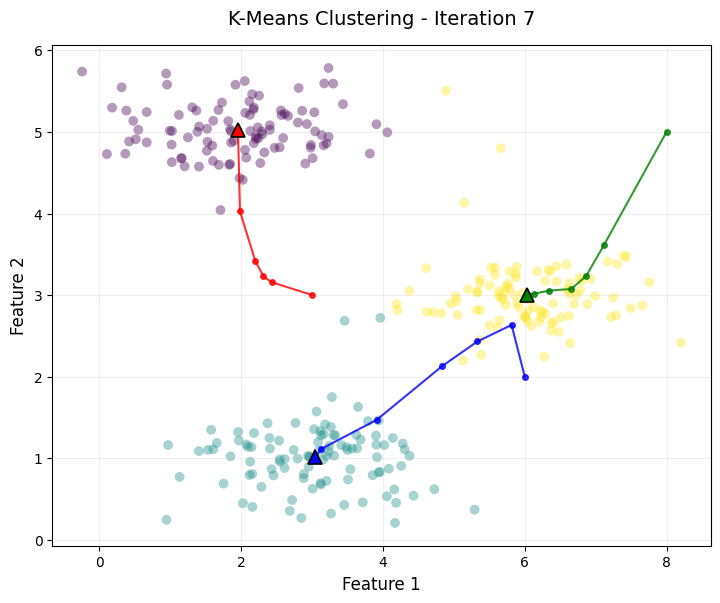

In [ ]:
X = load_data()
# Set initial centroids
initial_centroids = np.array([[3,3],[6,2],[8,5]])
# initial_centroids = np.array([[2.5,3.5],[2.2,4.8],[2.9,4.2]])
K = 3
# Number of iterations
max_iters = 8
centroids, index = run_kMeans(X, initial_centroids, max_iters,small_delay=0.2,check_convergence=False)